<a href="https://colab.research.google.com/github/LourdesAye/Proyecto_Machine_Learning/blob/main/Gonz%C3%A1lez_Lourdes_Ayel%C3%A9n_Comisi%C3%B3n_26141_TPI_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final Integrador: Predicción de Aprobación de Préstamos (Loan Prediction)

## 1. Selección del dataset y justificación
Para este proyecto final integrador, se ha seleccionado el dataset **Loan Prediction Problem Dataset** obtenido desde Kaggle.

* **Origen:** https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

* **Problema que aborda:** Se trata de un problema de **Clasificación Binaria**. En Machine Learning, se aplica clasificación cuando se busca predecir una categoría y no un valor numérico continuo. Específicamente, es "binaria" porque solo existen dos resultados posibles: predecir si un préstamo será aprobado o rechazado. Para que el algoritmo pueda procesarlo, la categoría de Aprobado (`Y`) se representará con un **1** y la de Rechazado (`N`) con un **0**. Entonces, la variable objetivo (o target) es `Loan_Status`.

* **Variables utilizadas:** Esta predicción se realiza en función de múltiples variables sociodemográficas y financieras del cliente, tales como su género, estado civil (si está casado o no), si tiene personas a cargo, su nivel de educación, si trabaja en relación de dependencia o no, sus ingresos, monto solicitado y su historial crediticio.

* **Justificación:** Este dataset representa un caso del sector financiero. Tiene una complejidad moderada (614 registros y 13 columnas), incluyendo variables numéricas y categóricas. Eso permite aplicar el análisis exploratorio de datos (EDA), limpieza de datos, transformaciones básicas, seleccionar las variables relevantes para el modelo y dividir el dataset en conjunto de entrenamiento y prueba.

## 2. Análisis Exploratorio Inicial (EDA)
Se carga el dataset a un Dataframe para conocer sus dimensiones, estructura, los tipos de datos, detectar variables numéricas y categóricas, obtener información de cada una de ellas, sus distribuciones, valores faltantes, análisis de correlaciones y visualizaciones básicas.

In [ ]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Herramientas de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [ ]:
# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
# Mostrar todas las filas en la salida
pd.set_option('display.max_rows', None)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [ ]:
# Instalación de librería para descarga automática del dataset desde Kaggle
!pip install kagglehub

In [ ]:
import kagglehub
import os

# Descarga automática del dataset
path = kagglehub.dataset_download(
    "altruistdelhite04/loan-prediction-problem-dataset"
)

print("Ruta del dataset:", path)

# Visualización de archivos descargados
print(os.listdir(path))

# Carga del dataset principal
ruta_csv = os.path.join(path, "train_u6lujuX_CVtuZ9i.csv")

df = pd.read_csv(ruta_csv)

Using Colab cache for faster access to the 'loan-prediction-problem-dataset' dataset.
Ruta del dataset: /kaggle/input/loan-prediction-problem-dataset
['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']


In [ ]:
# Inspección inicial: Cantidad de filas y columnas en el dataset
print("--- Dimensión del Dataset ---")
print(df.shape)

--- Dimensión del Dataset ---
(614, 13)


In [ ]:
# Inspección inicial: Columnas y tipos de datos
print("\n--- Tipos de datos por columna ---")
df.dtypes


--- Tipos de datos por columna ---


,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
# Inspección inicial: primeras cinco filas del dataset
print("\n--- Primeras filas ---")
display(df.head())



--- Primeras filas ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# Inspección inicial: últimas filas del dataset
print("\n--- Últimas filas ---")
display(df.tail())


--- Últimas filas ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [ ]:
# Inspección inicial: 5 filas aleatorias del dataset
print("\n--- 5 filas aleatorias ---")
display(df.sample(5, random_state=42))


--- 5 filas aleatorias ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
350,LP002139,Male,Yes,0,Graduate,No,9083,0.0,228.0,360.0,1.0,Semiurban,Y
377,LP002223,Male,Yes,0,Graduate,No,4310,0.0,130.0,360.0,NaN,Semiurban,Y
163,LP001570,Male,Yes,2,Graduate,No,4167,1447.0,158.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
132,LP001478,Male,No,0,Graduate,No,2718,0.0,70.0,360.0,1.0,Semiurban,Y


In [ ]:
# Inspección inicial: información general del dataset (columnas, tipos de datos, valores nulos)
print("\n--- Información del Dataset ---")
display(df.info())


--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


None

In [ ]:
# Inspección básica: estadísticas descriptivas de las variables numéricas
print("\n--- Estadísticas descriptivas ---")
display(df.describe())


--- Estadísticas descriptivas ---


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# Inspección Inicial: Conteo de valores nulos por columna ordenados de mayor a menor
print("\n--- Valores nulos por columna (ordenados) ---")
display(df.isnull().sum().sort_values(ascending=False))


--- Valores nulos por columna (ordenados) ---


,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3
Education,0
Loan_ID,0
CoapplicantIncome,0


In [ ]:
# Inspección inicial: Filas con valores nulos en la columna 'Married'
df[df['Married'].isnull()]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,LP001357,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y
228,LP001760,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,Y
435,LP002393,Female,NaN,NaN,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,Y


In [ ]:
# Inspección Inicial: Porcentaje de valores nulos por columna ordenados de mayor a menor
print("\n--- Porcentaje de valores nulos por columna (ordenados) ---")
display((df.isnull().mean().round(2) * 100).sort_values(ascending=False))



--- Porcentaje de valores nulos por columna (ordenados) ---


,0
Credit_History,8.0
Self_Employed,5.0
LoanAmount,4.0
Dependents,2.0
Gender,2.0
Loan_Amount_Term,2.0
Education,0.0
Loan_ID,0.0
Married,0.0
CoapplicantIncome,0.0


In [ ]:
# Inspección Inicial: Valores únicos por columna
# Esto ayuda a identificar variables categóricas, posibles errores de tipeo, la cardinalidad de cada columna
print("\n--- Valores únicos por columna ---")
display(df.nunique().sort_values(ascending=False))


--- Valores únicos por columna ---


,0
Loan_ID,614
ApplicantIncome,505
CoapplicantIncome,287
LoanAmount,203
Loan_Amount_Term,10
Dependents,4
Property_Area,3
Gender,2
Married,2
Education,2


In [ ]:
# Mostrar valores únicos de columnas con pocos valores
for col in ['Loan_Amount_Term','Dependents', 'Property_Area', 'Gender', 'Married',
            'Education', 'Self_Employed', 'Credit_History', 'Loan_Status']:
    print(f"\n{col}:")
    print(df[col].unique())


Loan_Amount_Term:
[360. 120. 240.  nan 180.  60. 300. 480.  36.  84.  12.]

Dependents:
['0' '1' '2' '3+' nan]

Property_Area:
['Urban' 'Rural' 'Semiurban']

Gender:
['Male' 'Female' nan]

Married:
['No' 'Yes' nan]

Education:
['Graduate' 'Not Graduate']

Self_Employed:
['No' 'Yes' nan]

Credit_History:
[ 1.  0. nan]

Loan_Status:
['Y' 'N']


In [ ]:
# Inspección Inicial: Número de filas duplicadas
# para limpiar el dataset de registros repetidos que podrían sesgar el modelo
print("\n--- Número de filas duplicadas ---")
display(df.duplicated().sum())


--- Número de filas duplicadas ---


np.int64(0)

In [ ]:
# inspección inicial: columnas numéricas
print("\n--- Columnas numéricas ---")
display(df.select_dtypes(include='number').head())


--- Columnas numéricas ---


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,5849,0.0,NaN,360.0,1.0
1,4583,1508.0,128.0,360.0,1.0
2,3000,0.0,66.0,360.0,1.0
3,2583,2358.0,120.0,360.0,1.0
4,6000,0.0,141.0,360.0,1.0


In [ ]:
# inspección inicial: columnas categóricas
print("\n--- Columnas categóricas ---")
display(df.select_dtypes(include='object').head())


--- Columnas categóricas ---


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,Urban,Y
4,LP001008,Male,No,0,Graduate,No,Urban,Y


### **Primeras conclusiones**

El dataset analizado contiene **614 registros** y **13 columnas**, combinando variables numéricas y categóricas relacionadas con solicitudes de préstamos.

Durante la inspección inicial se observó que el conjunto de datos presenta información vinculada tanto a las características personales y financieras del solicitante como al estado final de aprobación del préstamo.

A continuación se describen las variables principales detectadas:

---


#### **Variables categóricas (`object`)**

---

##### `Gender`
Representa el género del solicitante.  
Variable categórica nominal con dos categorías principales:

- Male
- Female

Posee **13 valores nulos**.

---

##### `Married`
Indica si el solicitante está casado o no.

Valores únicos:
- Yes
- No

Posee **3 valores nulos**.

---

##### `Dependents`
Representa la cantidad de personas dependientes económicamente del solicitante.

Valores observados:
- 0
- 1
- 2
- 3+

Posee **4 valores nulos**.

Esta variable presenta un caso particular importante: aunque representa una cantidad de dependientes, contiene el valor `3+`, por lo que pandas la interpreta como una variable categórica (`object`) y no como numérica. Esto deberá tenerse en cuenta para la codificación de variables.

---

##### `Education`
Representa el nivel educativo del solicitante.

Valores únicos:
- Graduate
- Not Graduate

No presenta valores nulos.

---

##### `Self_Employed`
Indica si el solicitante trabaja de forma autónoma o independiente (sin relación de dependencia).

Valores únicos:
- Yes
- No

Posee **32 valores nulos**.

---

##### `Property_Area`
Representa el tipo de zona donde se encuentra la propiedad.

Valores únicos:
- Rural
- Urban
- Semiurban

No presenta valores nulos.

---

##### `Loan_Status`
Representa el estado final de aprobación del préstamo y corresponde a la **variable objetivo (target)** del problema de Machine Learning.

Valores únicos:
- Y → préstamo aprobado
- N → préstamo rechazado

Es una variable categórica binaria y será la variable que el modelo intentará predecir utilizando el resto de las variables del dataset.

No presenta valores nulos.

---

#### **Variables numéricas (`int64` y `float64`)**

---

##### `ApplicantIncome`
Representa los ingresos del solicitante principal.

Es una variable numérica de tipo `int64` y no presenta valores nulos.

---

##### `CoapplicantIncome`
Representa los ingresos del co-solicitante, es decir, otra persona que participa de la solicitud del préstamo.

Es una variable numérica de tipo `float64` y no presenta valores nulos.

---

##### `LoanAmount`
Representa el monto solicitado para el préstamo.

Es una variable numérica de tipo `float64` y presenta **22 valores nulos**.

---

##### `Loan_Amount_Term`
Representa el plazo de duración del préstamo.

Es una variable numérica de tipo `float64`.

Los valores observados indican que el plazo se encuentra expresado en meses. Por ejemplo:

- 360 meses → 30 años
- 120 meses → 10 años

Posee valores nulos que deberán tratarse en etapas posteriores.

---

##### `Credit_History`
Representa el historial crediticio del solicitante.

Valores observados:
- 1 → historial crediticio favorable
- 0 → historial crediticio desfavorable

Aunque técnicamente es una variable numérica (`float64`), conceptualmente funciona como una variable binaria categórica.

Posee **50 valores nulos**, siendo una de las columnas con mayor cantidad de datos faltantes del dataset.

---

### Conclusiones generales iniciales

- se detectó la presencia de valores nulos en varias columnas, especialmente en `Credit_History`, `Self_Employed` y `LoanAmount`, lo que requerirá un tratamiento de los mismos.

- Las variables numéricas relacionadas con ingresos y montos (`ApplicantIncome`, `CoapplicantIncome` y `LoanAmount`) podrían presentar valores atípicos (*outliers*), por lo que será importante analizarlas mediante gráficos.

- Finalmente, al tratarse de un problema de clasificación binaria, el objetivo del proyecto será construir un modelo capaz de predecir si un préstamo será aprobado o rechazado en función de las características financieras y personales del solicitante.

#### Análisis de Variables categóricas
- Se va a definir la lista de variables categóricas a analizar
    - Se incluye `Credit_History` porque, aunque es numérica 1.0/0.0 (float64), conceptualmente es categórica

- Se itera sobre cada columna categórica para mostrar los conteos o frecuencias, porcentajes y gráficos
    -  Visualización usando countplot (Gráfico de Barras) con :
        - tamaño estándar de la figura en pulgadas (ancho=6, alto=4)
        - data: DataFrame con la información
        - x: columna usada en el eje X

--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---

Distribución de la columna: Gender


,Cantidad,Porcentaje
Gender,,
Male,489,80.0
Female,112,18.0
NaN,13,2.0


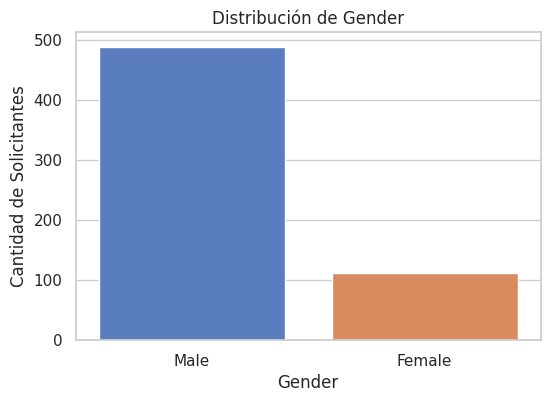

------------------------------------------------------------

Distribución de la columna: Married


,Cantidad,Porcentaje
Married,,
Yes,398,65.0
No,213,35.0
NaN,3,0.0


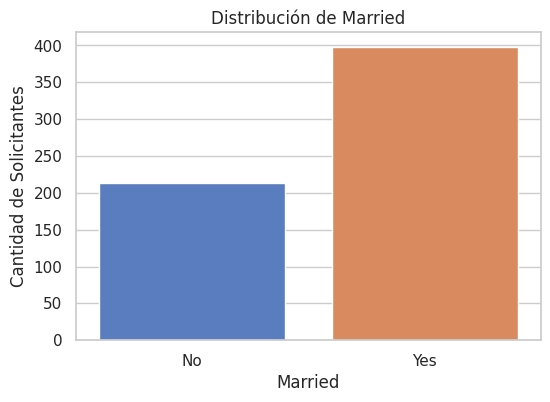

------------------------------------------------------------

Distribución de la columna: Dependents


,Cantidad,Porcentaje
Dependents,,
0,345,56.0
1,102,17.0
2,101,16.0
3+,51,8.0
NaN,15,2.0


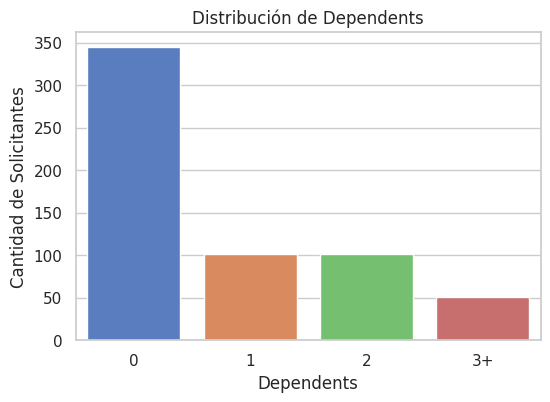

------------------------------------------------------------

Distribución de la columna: Education


,Cantidad,Porcentaje
Education,,
Graduate,480,78.0
Not Graduate,134,22.0


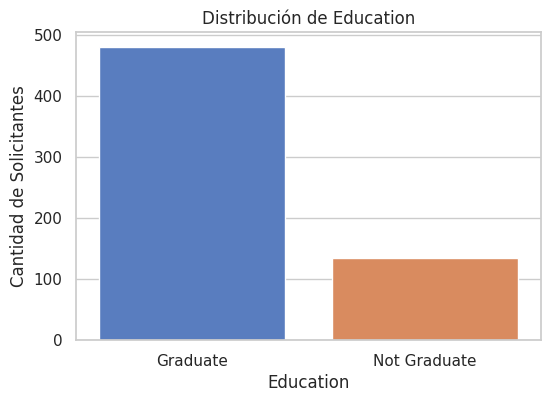

------------------------------------------------------------

Distribución de la columna: Self_Employed


,Cantidad,Porcentaje
Self_Employed,,
No,500,81.0
Yes,82,13.0
NaN,32,5.0


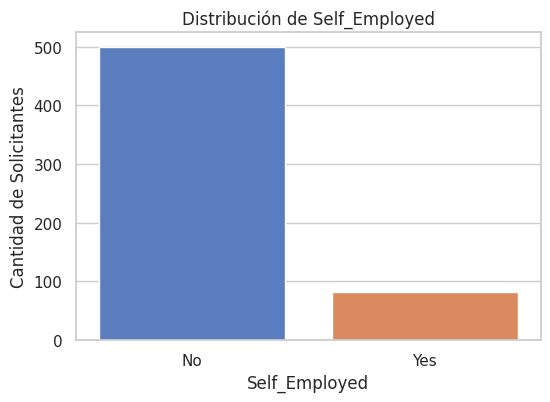

------------------------------------------------------------

Distribución de la columna: Property_Area


,Cantidad,Porcentaje
Property_Area,,
Semiurban,233,38.0
Urban,202,33.0
Rural,179,29.0


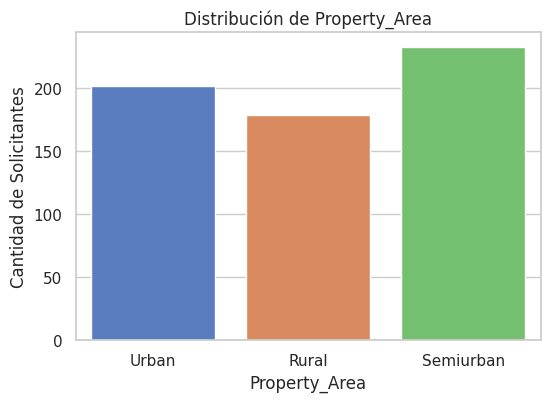

------------------------------------------------------------

Distribución de la columna: Credit_History


,Cantidad,Porcentaje
Credit_History,,
1.0,475,77.0
0.0,89,14.0
NaN,50,8.0


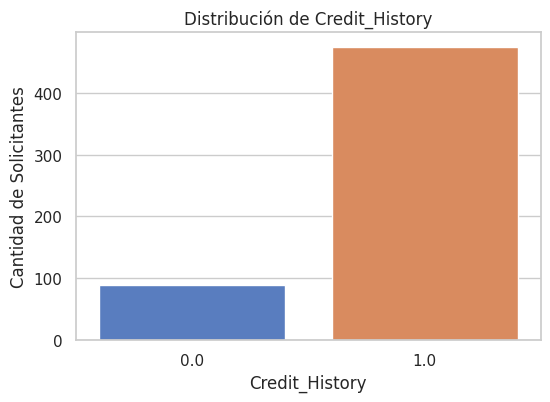

------------------------------------------------------------

Distribución de la columna: Loan_Status


,Cantidad,Porcentaje
Loan_Status,,
Y,422,69.0
N,192,31.0


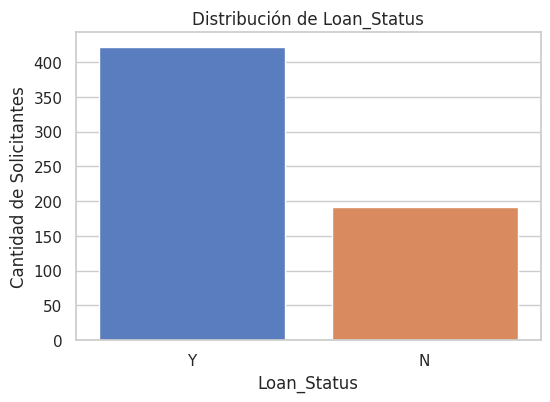

------------------------------------------------------------


In [ ]:

columnas_categoricas = ['Gender', 'Married', 'Dependents', 'Education',
                        'Self_Employed', 'Property_Area', 'Credit_History', 'Loan_Status']

print("--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---")

for col in columnas_categoricas:
    print(f"\nDistribución de la columna: {col}")

    tabla = pd.DataFrame({
        'Cantidad': df[col].value_counts(dropna=False),
        'Porcentaje': df[col].value_counts(normalize=True, dropna=False).round(2) * 100
    })
    display(tabla)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue=col, legend=False)
    plt.title(f'Distribución de {col}')
    plt.ylabel('Cantidad de Solicitantes')
    plt.show()
    print("-" * 60)


### Conclusiones del análisis de variables categóricas

A partir de la visualización y análisis de las variables categóricas del dataset, se pudieron identificar distintas distribuciones y características relevantes para el problema de clasificación.

#### Gender
Se observa un fuerte predominio de solicitantes masculinos (`Male`), representando aproximadamente el 80% de los registros, mientras que las solicitantes femeninas (`Female`) representan cerca del 18%. Además, la columna presenta un pequeño porcentaje de valores nulos (2%).

Esto indica un posible desbalance en la representación de género dentro del dataset.

---

#### Married
La mayoría de los solicitantes se encuentran casados (`Yes`), representando aproximadamente el 65% de los registros, frente al 35% de personas no casadas (`No`).

La columna presenta muy pocos valores nulos.

---

#### Dependents
La categoría más frecuente corresponde a solicitantes sin dependientes (`0`), con aproximadamente el 56% de los registros.

También se observa que la cantidad de solicitantes disminuye a medida que aumenta la cantidad de dependientes.

Además, esta variable presenta una característica particular: el valor `3+` representa tres o más dependientes, lo que provoca que la columna sea interpretada como categórica (`object`) en lugar de numérica.

---

#### Education
La mayoría de los solicitantes poseen estudios de grado (`Graduate`), representando aproximadamente el 78% de los casos.

La columna no presenta valores nulos.

---

#### Self_Employed
La gran mayoría de los solicitantes no son trabajadores autónomos (`No`), representando aproximadamente el 81% de los registros.

La columna presenta un 5% de valores nulos, por lo que requerirá tratamiento posterior.

---

#### Property_Area
La distribución entre zonas geográficas se encuentra relativamente equilibrada.

La categoría más frecuente es `Semiurban` (38%), seguida por `Urban` (33%) y `Rural` (29%).

Esto podría resultar útil para analizar posteriormente si la ubicación influye en la aprobación del préstamo.

---

#### Credit_History
La mayoría de los solicitantes poseen historial crediticio favorable (`1.0`), representando aproximadamente el 77% de los registros.

Por otro lado, el 14% posee historial desfavorable (`0.0`), mientras que esta variable presenta un porcentaje relativamente importante de valores nulos (8%).

Debido a su naturaleza financiera, esta columna podría tener una fuerte relación con la aprobación o rechazo del préstamo.

---

#### Loan_Status (Variable Objetivo)
La variable objetivo presenta un desbalance moderado hacia préstamos aprobados (`Y`), los cuales representan aproximadamente el 69% de los casos.

Los préstamos rechazados (`N`) representan cerca del 31%.

Esto indica que el dataset contiene una mayor proporción de aprobaciones, aspecto que deberá tenerse en cuenta durante el entrenamiento y evaluación del modelo de clasificación.

---



#### Análisis de Variables Numéricas
- Se define qué variables numéricas se van a analizar
- Se utiliza plt.subplots(1, 2, figsize=(12,4))
    - devuelve una figura con dos subgráficos (ax[0] y ax[1]) para mostrar el histograma y el boxplot lado a lado.
        - subplots crea una figura
        - 1 = cantidad de filas y 2 = cantidad de columnas
        - figsize=(12,4) =  tamaño total de la figura
- Histograma para ver distribución : sns.histplot(), con los siguientes parámetros:
    - data : dataframe
    - x: columna que se analiza
    - kde : agrega curva
    - ax : dónde se va a graficar
- Se agrega al Historgrama media y mediana
    - ax: en qué grafico se dibuja
    - axvline() : dibuja línea vertical
    - primer parámetro: valor de x en el que se dibuja dicha línea vertical
    - linestyle='--' : línea punteada
    - linewidth=2: grosor
    - label=	texto leyenda
        - en distribuciones sesgadas la media y mediana se separan
            - media es sensible a outliers


- Boxplot para detectar outliers: sns.boxplot(data=df, x=col, ax=ax[1], color='lightgreen')
    - data : dataframe
    - x : columna que se analiza
    - ax : dónde se va a graficar
- plt.tight_layout() ajusta espacios automáticamente.
    - evita títulos encimados y gráficos cortados

--- DISTRIBUCIÓN DE VARIABLES NUMÉRICAS Y DETECCIÓN DE OUTLIERS ---

Análisis de la columna: ApplicantIncome


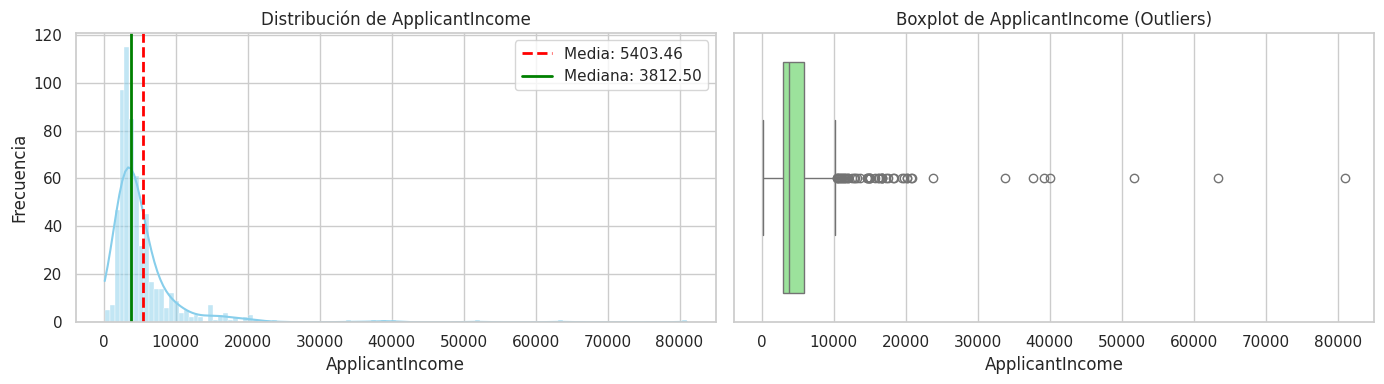

Media: 5403.46
Mediana: 3812.50
--------------------------------------------------------------------------------

Análisis de la columna: CoapplicantIncome


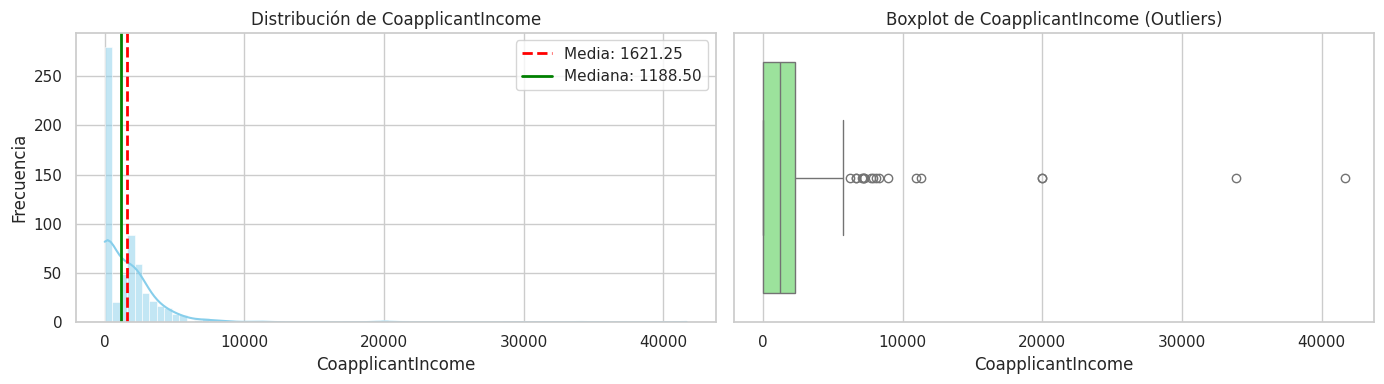

Media: 1621.25
Mediana: 1188.50
--------------------------------------------------------------------------------

Análisis de la columna: LoanAmount


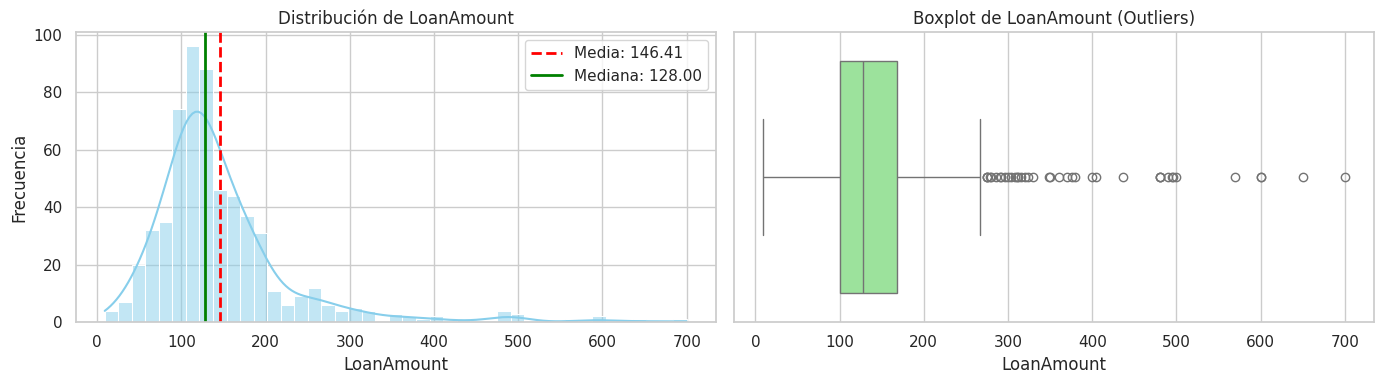

Media: 146.41
Mediana: 128.00
--------------------------------------------------------------------------------

Análisis de la columna: Loan_Amount_Term


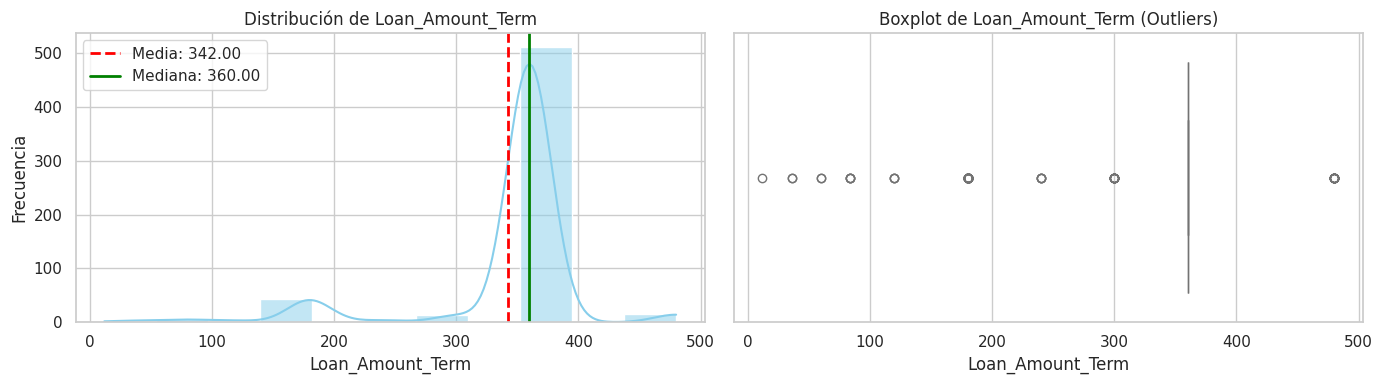

Media: 342.00
Mediana: 360.00
--------------------------------------------------------------------------------


In [ ]:
columnas_numericas = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

print("--- DISTRIBUCIÓN DE VARIABLES NUMÉRICAS Y DETECCIÓN DE OUTLIERS ---")

for col in columnas_numericas:
    print(f"\nAnálisis de la columna: {col}")

    # Cálculo de media y mediana
    media = df[col].mean()
    mediana = df[col].median()

    # Figura con dos subgráficos
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Histograma
    sns.histplot(data=df, x=col, kde=True, ax=ax[0], color='skyblue')

    # Línea de media
    ax[0].axvline(media, color='red', linestyle='--', linewidth=2,
                  label=f'Media: {media:.2f}')

    # Línea de mediana
    ax[0].axvline(mediana, color='green', linestyle='-', linewidth=2,
                  label=f'Mediana: {mediana:.2f}')

    ax[0].set_title(f'Distribución de {col}')
    ax[0].set_ylabel('Frecuencia')
    ax[0].legend()

    # Boxplot
    sns.boxplot(data=df, x=col, ax=ax[1], color='lightgreen')
    ax[1].set_title(f'Boxplot de {col} (Outliers)')

    plt.tight_layout()
    plt.show()

    print(f"Media: {media:.2f}")
    print(f"Mediana: {mediana:.2f}")

    print("-" * 80)

### Notas
Sesgo
- NO depende de dónde está la CONCENTRACIÓN principal
- **DEPENDE** de hacia dónde se extiende la **COLA**
- Ejemplo
    - **MUCHOS** valores **BAJOS** y **POCOS** valores MUY **ALTOS**
        - la cola larga se extiende hacia la derecha ███████████▆▅▃▂▁______________
            - right skew o sesgo positivo o asimetría positiva (o hacia la derecha)
- En distribuciones con sesgo positivo los outliers grandes “arrastran” la media hacia la derecha.
    - Por eso normalmente ocurre media > mediana

In [ ]:
print("\n--- DETECCIÓN DE OUTLIERS (Método IQR) ---")

for col in columnas_numericas:

    # Cálculo de cuartiles
    Q1 = df[col].quantile(0.25) # percentil 25
    Q3 = df[col].quantile(0.75) # percentil 75

    # Rango intercuartílico (rango central de datos. Excluye el 25% inferior y el 25% superior)
    IQR = Q3 - Q1

    # Límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Detección de outliers: menores al límite inferior o mayores al superior.
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    # Número de filas que cumplen la condición de ser outliers
    cantidad_outliers = outliers.shape[0]
    porcentaje = (cantidad_outliers / df.shape[0]) * 100

    print(f"\nVariable: {col}")
    print(f"Cantidad de outliers: {cantidad_outliers}")
    print(f"Porcentaje de outliers: {porcentaje:.2f}%")


--- DETECCIÓN DE OUTLIERS (Método IQR) ---

Variable: ApplicantIncome
Cantidad de outliers: 50
Porcentaje de outliers: 8.14%

Variable: CoapplicantIncome
Cantidad de outliers: 18
Porcentaje de outliers: 2.93%

Variable: LoanAmount
Cantidad de outliers: 39
Porcentaje de outliers: 6.35%

Variable: Loan_Amount_Term
Cantidad de outliers: 88
Porcentaje de outliers: 14.33%


### Notas
Outlier
- **NO** signfica **error necesariamente**.
- Especialmente en finanzas, ingresos y préstamos
- Puede ser comportamiento real.
    - Ejemplo: una persona con ingreso extremadamente alto NO necesariamente es dato incorrecto. Puede ser cliente muy rico.

### Conclusiones del análisis de variables numéricas

Las variables `ApplicantIncome` y `CoapplicantIncome` presentan distribuciones fuertemente asimétricas hacia la derecha (sesgo positivo). Esto indica que la mayoría de los solicitantes poseen ingresos bajos o moderados, mientras que una pequeña proporción presenta ingresos considerablemente más altos.

En ambos casos, los boxplots permitieron detectar numerosos valores atípicos (*outliers*), especialmente en `ApplicantIncome`, donde existen registros extremadamente alejados del rango principal de datos.  Mediante el método del rango intercuartílico (IQR), se identificaron 50 outliers en `ApplicantIncome`, representando aproximadamente el 8.14% del dataset. En `CoapplicantIncome` se detectaron 18 outliers (2.93%).

Este comportamiento es esperable en datasets financieros, ya que suele existir una minoría de personas con ingresos significativamente superiores al promedio.

La variable `CoapplicantIncome` presenta además una fuerte concentración de valores cercanos a cero, lo que podría indicar que muchos solicitantes no poseen co-solicitante o que éste no aporta ingresos relevantes al préstamo.

Por otro lado, la variable `LoanAmount` muestra una distribución más cercana a una campana, aunque todavía conserva cierto sesgo positivo y presencia de valores atípicos. La mayor concentración de préstamos se encuentra en montos intermedios, mientras que una pequeña cantidad de solicitudes corresponde a montos considerablemente más elevados. A través del método IQR se detectaron 39 outliers en esta variable, equivalentes al 6.35% de los registros.

Finalmente, `Loan_Amount_Term` presenta una distribución altamente concentrada alrededor del valor 360, correspondiente a préstamos de 30 años de duración. Esto indica la existencia de un plazo predominante dentro del dataset. Debido a esta fuerte concentración, otros valores de plazo aparecen visualmente como outliers en el boxplot, aunque no necesariamente representan errores o anomalías reales. En esta variable se detectaron 88 outliers (14.33%), aunque en este caso muchos de ellos podrían corresponder simplemente a plazos menos frecuentes y no a datos incorrectos.

Dado el contexto financiero del dataset, los valores extremos detectados no fueron eliminados en esta etapa, ya que podrían representar casos reales y relevantes para el comportamiento del modelo.

### Análisis de Correlaciones y Feature Engineering

- Se va a generar una **matriz de correlación** para entender cómo se relacionan las variables numéricas entre sí y con la variable objetivo o target `Loan_Status`.
    - Correlación : es una medida estadística que indica qué tan relacionadas están dos variables
        - Devuelve valores entre −1 y 1.
            -  1 : correlación positiva perfecta (cuando una sube, la otra también)
            -  0 : sin correlación  (no hay relación lineal)
            - -1 : correlación negativa perfecta (cuando una sube, la otra baja)
        - Fuerza de correlación
            - entre 0  y 0.3 : débil
            - entre 0.3 y 0.6 : moderada
            - entre 0.6 y 1 : fuerte

- Aplicación de **Feature Engineering**:
    - **Creación de nueva variable:** Se sumarán `ApplicantIncome` y `CoapplicantIncome` para crear la variable `Ingreso_Total`, ya que la capacidad de pago real de la familia depende de la suma de ambos.

- **Transformación de la variable objetivo (target) para graficar:** Se va a mapear `Loan_Status` ('Y'/'N') a valores binarios numéricos (1/0) porque corr() en python solo funciona con números y de esta manera se va poder medir corrrelación con aprobación del préstamo.

- Se utiliza un mapa de calor para mostrar la matriz de correlación, cada celda indica la relación entre dos variables.
    - Los colores ayudan a identificar rápidamente correlaciones fuertes o débiles.
    - sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        - data : matriz de correlación a graficar
        - annot=True : muestra los números dentro de la celda
        - cmap='coolwarm' : define gama de colores
        - fmt=".2f" : formato de los números (2 decimales)
        - linewidths=0.5 : grosor de las líneas entre celdas

--- Análisis de Correlación ---


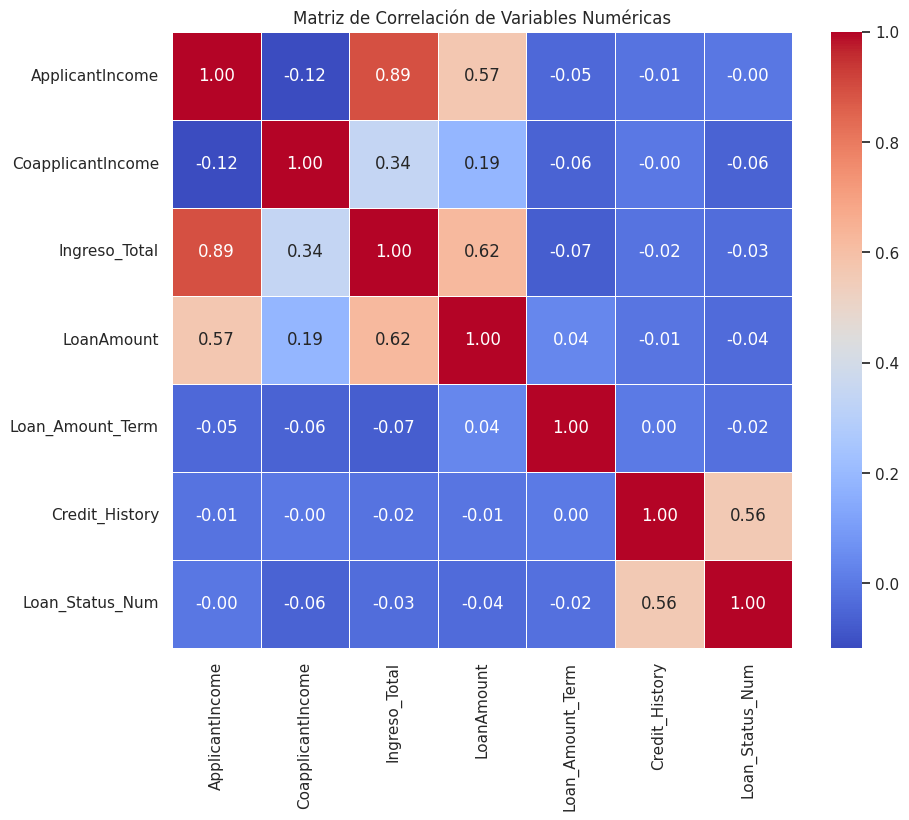

In [ ]:
print("--- Análisis de Correlación ---")
# Feature Engineering: Creación de Ingreso_Total
df['Ingreso_Total'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Transformación de la variable objetivo o target Load_Status a formato numérico para el gráfico ( Y → 1 , N → 0)
df['Loan_Status_Num'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Variables numéricas relevantes para la matriz
columnas_corr = ['ApplicantIncome', 'CoapplicantIncome', 'Ingreso_Total',
                 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status_Num']

# Cálculo de correlaciones
matriz_correlacion = df[columnas_corr].corr()

# Visualización con un Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()



### Conclusiones del Análisis de Correlaciones

Al observar el mapa de calor (Heatmap) para mostrar las correlaciones se concluye lo siguiente:  

- la correlación positiva más fuerte con la aprobación del préstamo (`Loan_Status_Num`) corresponde a la variable `Credit_History` (0.56). Esto indica que los solicitantes con buen historial crediticio poseen una probabilidad considerablemente mayor de obtener la aprobación del préstamo.

- hay una correlación positiva moderada (0.62) entre `Ingreso_Total` y `LoanAmount`(monto del préstamo). Esto resulta coherente desde el punto de vista financiero, ya que las personas o familias con mayores ingresos tienden a solicitar préstamos de montos más elevados.

- existe una correlación muy alta entre `ApplicantIncome` e `Ingreso_Total` (0.89). Esto ocurre porque la nueva variable creada (`Ingreso_Total`) depende directamente del ingreso principal del solicitante. En cambio, `CoapplicantIncome` presenta una correlación mucho menor con el ingreso total (0.34), lo que sugiere que en muchos casos el ingreso principal es el componente dominante del total familiar.

- las variables `ApplicantIncome`, `CoapplicantIncome`, `LoanAmount` y `Loan_Amount_Term` presentan correlaciones muy bajas o prácticamente nulas con `Loan_Status_Num`. Esto indica que, individualmente, estas variables parecen tener poca relación lineal directa con la aprobación del préstamo.

- se ve una leve correlación negativa entre `CoapplicantIncome` y `Loan_Status_Num` (-0.06), aunque su magnitud es demasiado baja como para considerarse relevante en esta etapa del análisis.

### Limpieza de Datos y División (Train/Test Split)

- **Limpieza de columnas:**
    - Se eliminaran las columnas:
        - `Loan_ID` ya que es un identificador y no aporta valor predictivo.
        - `ApplicantIncome` y `CoapplicantIncome` dado que ya se creo la variable `Ingreso_Total`.

- **Verificación o Transformación de la Transformación del Target:**
    - La variable objetivo `Loan_Status` debe estar en formato numérico binario (1 y 0).
    
- **División de Datos:**
    - Separación de los datos en un conjunto de Entrenamiento (80%) y uno de Prueba (20%). Lo que resulta fundamental para evaluar si el modelo logra generalizar correctamente sobre datos nuevos y prevenir el sobreajuste (*overfitting*).


In [ ]:
print("\n--- Eliminación de Columnas irrelevantes o redundantes ---\n")
columnas_a_eliminar = ['Loan_ID', 'ApplicantIncome', 'CoapplicantIncome']
df.info()
df_clean = df.drop(columns=columnas_a_eliminar, errors='ignore')
print(f"Columnas eliminadas:  {columnas_a_eliminar}\n")
df_clean.info()


--- Eliminación de Columnas irrelevantes o redundantes ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
 13  Ingreso_Total      614 non-null    float64
 14  Loan_Status_Num    614 non-null    int64  
dtypes: float64(5)

In [ ]:
# Se verifica que variable objetivo sea numérica (1 = Aprobado, 0 = Rechazado)
display(df_clean['Loan_Status_Num'].dtypes)

dtype('int64')

In [ ]:
# se había mapeado como 'Loan_Status_Num', por lo que se usa y se borra la original de texto
if 'Loan_Status_Num' in df_clean.columns:
    df_clean['Loan_Status'] = df_clean['Loan_Status_Num']
    df_clean = df_clean.drop(columns=['Loan_Status_Num'])
df_clean.info()
print("\n--- Tipo de dato de la variable objetivo 'Loan_Status' ---")
display(df_clean['Loan_Status'].dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            601 non-null    object 
 1   Married           611 non-null    object 
 2   Dependents        599 non-null    object 
 3   Education         614 non-null    object 
 4   Self_Employed     582 non-null    object 
 5   LoanAmount        592 non-null    float64
 6   Loan_Amount_Term  600 non-null    float64
 7   Credit_History    564 non-null    float64
 8   Property_Area     614 non-null    object 
 9   Loan_Status       614 non-null    int64  
 10  Ingreso_Total     614 non-null    float64
dtypes: float64(4), int64(1), object(6)
memory usage: 52.9+ KB

--- Tipo de dato de la variable objetivo 'Loan_Status' ---


dtype('int64')

### Nota
- Si `Loan_Status` no hubiera sido una columna numérica, se tendría que haber tranformado de la siguiente forma:
    - df_clean['Loan_Status'] = df_clean['Loan_Status'].map({'Y': 1, 'N': 0})

- Previamente, en el análisis se detectó que la columna numérica `Loan_Status` no tenía nulos.
    - Si los hubiese tenido se debían eliminar
        - df_clean = df_clean.dropna(subset=['Loan_Status'])

In [ ]:
print("\n--- Separación en X (variables predictoras) e y (variable objetivo) ---")
X = df_clean.drop('Loan_Status', axis=1)
y = df_clean['Loan_Status']

print("\n--- División en Entrenamiento (80%) y Prueba (20%) ---\n")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Tamaño del conjunto de Entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño del conjunto de Prueba (X_test): {X_test.shape}")


--- Separación en X (variables predictoras) e y (variable objetivo) ---

--- División en Entrenamiento (80%) y Prueba (20%) ---

Tamaño del conjunto de Entrenamiento (X_train): (491, 10)
Tamaño del conjunto de Prueba (X_test): (123, 10)


### Notas
- Los datos aún tienen valores nulos y mezclan texto con números de distintas escalas.
- Se va a armar `ColumnTransformer` para procesar todo de forma conjunta:
    - **Variables Numéricas:** Se imputaran los nulos con el valor medio (`SimpleImputer`) y se aplicará `StandardScaler`.
        - Esto estandarizará las escalas para que algoritmos sensibles a la distancia no se sesguen.
    - **Variables Categóricas:** Se imputaran los nulos con la moda (el valor más frecuente) y se aplicará `OneHotEncoder` para convertir el texto a formato binario matemático sin generar un orden jerárquico artificial.


In [ ]:
# Identificación automática de las columnas por su tipo
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Procesamiento de datos numéricos
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Procesamiento de datos categóricos
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Se combinan ambos pipelines en un único ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Se visualiza la estructura del preprocesador
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Ingreso_Total'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])

### Conclusiones de limpieza y preprocesamiento

- En esta etapa se prepararon los datos para el modelado predictivo.
    - Se eliminaron variables irrelevantes o redundantes, como `Loan_ID` y los ingresos individuales, priorizando la nueva variable `Ingreso_Total`.
    - Se transformó la variable objetivo `Loan_Status` a formato numérico binario para permitir su utilización en algoritmos de clasificación.
    - El dataset fue dividido en conjuntos de entrenamiento y prueba utilizando una proporción 80/20 y preservando la distribución de clases mediante stratify.
    - Se construyó un sistema de preprocesamiento automatizado mediante Pipeline y ColumnTransformer, permitiendo tratar correctamente valores nulos, escalar variables numéricas y codificar variables categóricas de forma consistente y reutilizable.

### Entrenamiento del Modelo de Clasificación

- Para resolver un problema de clasificación binaria (donde se busca predecir entre dos opciones: 1 o 0), se utiliza el modelo de **Regresión Logística**.
    - A diferencia de la regresión lineal que predice un número continuo, la regresión logística estima la probabilidad de que un caso pertenezca a una clase u otra y aplica un umbral para tomar una decisión final.

- Se integra preprocesador (`ColumnTransformer`) y el modelo clasificador en un solo `Pipeline` para automatizar el flujo.

- Se entrena el modelo usando exclusivamente el conjunto de datos de entrenamiento (`X_train` e `y_train`).

In [ ]:
# Pipeline final integrando el preprocesamiento y el modelo
modelo_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Entrenamiento del modelo
modelo_pipeline.fit(X_train, y_train)

print("¡El modelo de Regresión Logística ha sido entrenado exitosamente!")

¡El modelo de Regresión Logística ha sido entrenado exitosamente!


### Notas
- Es importante integrar el `preprocessor` y el modelo dentro de un único `Pipeline`, en lugar de aplicar transformaciones manualmente antes del entrenamiento.
    - Esto evita problemas de *data leakage*, es decir, que el modelo tenga acceso indirecto a información del conjunto de prueba durante el entrenamiento, lo que podría sesgar las métricas y generar una falsa sensación de rendimiento.
    - De esta manera, transformaciones como imputación, escalado y codificación categórica se ajustan únicamente con los datos de entrenamiento y luego se aplican correctamente sobre los datos de prueba.

### Medición de desempeño del modelo
- Se van a realizar predicciones sobre el conjunto de prueba (`X_test`), es decir, datos que el modelo nunca ha visto durante su entrenamiento.
- En problemas de clasificación no basta con mirar solo la exactitud general (Accuracy). Por eso, se utilizan métricas de evaluación específicas:
    - **Reporte de Clasificación:** Para observar el *Recall* (sensibilidad) y el *F1-Score*, evaluando cómo se comporta con cada clase por separado
    - **Matriz de Confusión:** Para analizar en detalle cómo se componen los aciertos y los errores (Verdaderos Positivos, Falsos Positivos, etc.).

Accuracy General: 0.8537

--- REPORTE DE CLASIFICACIÓN ---
               precision    recall  f1-score   support

Rechazado (0)       0.95      0.55      0.70        38
 Aprobado (1)       0.83      0.99      0.90        85

     accuracy                           0.85       123
    macro avg       0.89      0.77      0.80       123
 weighted avg       0.87      0.85      0.84       123



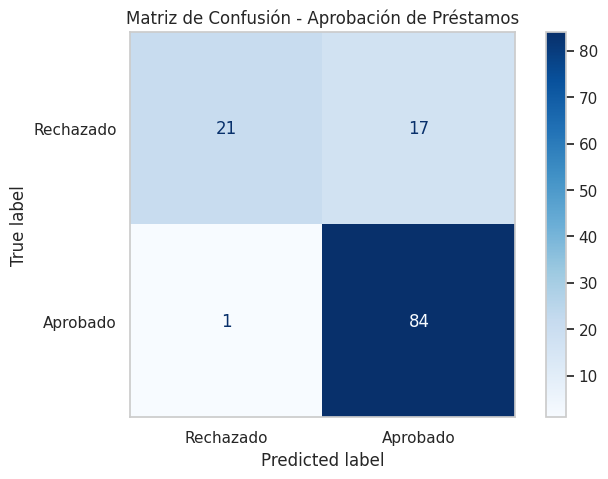

In [ ]:
# Se generan las predicciones sobre el conjunto de prueba
y_pred = modelo_pipeline.predict(X_test)

# Precisión General (Accuracy)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy General: {accuracy:.4f}\n")

# Reporte de clasificación (Precision, Recall, F1-Score)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Rechazado (0)', 'Aprobado (1)']))

# Matriz de Confusión
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Rechazado', 'Aprobado'], cmap='Blues')
plt.title('Matriz de Confusión - Aprobación de Préstamos')
plt.grid(False) # Quitamos la grilla de fondo para que la matriz se vea más limpia
plt.show()


### Conclusiones y Análisis de Resultados

- A lo largo del proyecto se desarrolló un pipeline completo de Machine Learning orientado a la predicción de aprobación de préstamos utilizando un modelo de Regresión Logística.

- El trabajo incluyó todas las etapas fundamentales del ciclo de vida de un proyecto de datos: carga y exploración inicial del dataset, análisis exploratorio (EDA), tratamiento de valores faltantes y outliers, transformación y codificación de variables, creación de nuevas características mediante Feature Engineering, división en conjuntos de entrenamiento y prueba, automatización del preprocesamiento mediante Pipeline y ColumnTransformer, entrenamiento del modelo y evaluación mediante métricas de clasificación.

- El modelo obtuvo un Accuracy aproximado del 85%, demostrando un buen desempeño general como modelo baseline. Sin embargo, el análisis detallado de las métricas evidenció ciertas dificultades para identificar correctamente préstamos rechazados, probablemente debido al desbalance presente en la variable objetivo.

- El dataset presenta un desbalance moderado entre clases, con una mayor proporción de préstamos aprobados. Esto influye en el comportamiento del modelo, que logra un desempeño considerablemente mejor sobre la clase mayoritaria (Aprobado) que sobre la clase minoritaria (Rechazado).

- Finalmente, el proyecto permitió aplicar conceptos fundamentales de Machine Learning supervisado, preprocesamiento de datos y evaluación de modelos predictivos en un caso de negocio real del ámbito financiero.



### Anexo

* **Fuente del Dataset "Loan Prediction Problem Dataset"**
  - Extraído de Kaggle, cuyo enlace es:
    - https://www.kaggle.com/datasets/altruistdelhite04/loan-prediction-problem-dataset

* **Instrucciones de Ejecución del Notebook**
  - **Opción 1: Ejecución Automática:**
    - El notebook está configurado por defecto para descargar el dataset directamente desde Kaggle utilizando la librería `kagglehub`. No se requiere subir ningún archivo manualmente; simplemente ejecutar todas las celdas.
  - **Opción 2: Ejecución Local:**
    - Si se desea ejecutar de manera local, el archivo `train_prestamos.csv` se encuentra en el siguiente enlace:
      - https://drive.google.com/file/d/1jW46-H0wEdyCLml0knnOXad-gdoW7Pdd/view?usp=drive_link
    - Para esta opción, se debe crear la estructura de carpetas `data/raw/` en el entorno local, colocar allí el archivo `train_prestamos.csv` y reemplazar el bloque de código de `kagglehub` inicial por el siguiente:
      ```python
      df = pd.read_csv('data/raw/train_prestamos.csv')
      ```

* **Estructura de Carpetas de la Entrega (Drive)**
  - **Carpeta Principal:** González Lourdes Ayelén - Comisión 26141 - TPI Machine Learning
    - Enlace: https://drive.google.com/drive/folders/1FHjQlAz0spN-uYdkjS6W5r-gAFdi_y9g?usp=drive_link
  - **Subcarpeta de dataset:** `data/raw/`
    - Enlace al archivo: https://drive.google.com/file/d/1jW46-H0wEdyCLml0knnOXad-gdoW7Pdd/view?usp=drive_link

* **Referencias usadas**
  - Teoría y material de estudio del trayecto Machine Learning de Talento Tech, comisión 26141.